# Parametrización espectral


***

![voyteklab](./data/voyteklab.png)

***


## Algoritmo de ajuste

Una descripción paso a paso del algoritmo para parametrizar espectros de potencia neurales (neural power spectra). Basado en el método descrito en:


Donoghue T, Haller M, Peterson EJ, Varma P, Sebastian P, Gao R, Noto T, Lara AH, Wallis JD,
Knight RT, Shestyuk A, & Voytek B (2020). Parameterizing neural power spectra into periodic
and aperiodic components. *Nature Neuroscience, 23*, 1655-1665.
[DOI: 10.1038/s41593-020-00744-x](https://doi.org/10.1038/s41593-020-00744-x) 

Tutorial escrito originalmente por Thomas Donoghue. Adaptado para 2026 por Sydney Smith, Eena Kosik y Quirine Van Engen.

### Descripción algorítmica

En este tutorial recorreremos paso a paso cómo se ajusta el modelo del espectro de potencia (power spectrum).

Ten en cuenta que este notebook es solo con fines demostrativos y no representa el uso recomendado para ajustar modelos del espectro de potencia.

En términos generales, los pasos del algoritmo son:

1. Se calcula un ajuste inicial del componente aperiódico a partir del espectro de potencia.
2. Ese ajuste aperiódico se resta del espectro de potencia, creando un espectro aplanado.
3. Un proceso iterativo identifica picos en este espectro aplanado.
4. Se vuelve a ajustar un modelo completo de picos usando todos los candidatos identificados.
5. El ajuste de los picos se resta del espectro de potencia original, creando un espectro al que se le removieron los picos.
6. Se realiza un ajuste final del componente aperiódico sobre este espectro sin picos.
7. El modelo completo se reconstruye a partir de la combinación de los ajustes aperiódico y de picos, y se calculan métricas de calidad de ajuste.

### Preparación

In [18]:
# Instalar paquetes necesarios (colab)
!pip install fooof

In [19]:
# Paquetes generales
import matplotlib.pyplot as plt

# FOOF!
from fooof import FOOOF

# Funciones particulares de FOOD
# Estas funciones no son necesarias siempre necesarias.
from fooof.sim.gen import gen_aperiodic
from fooof.plts.spectra import plot_spectrum
from fooof.plts.annotate import plot_annotated_peak_search

# Descargar y cargar datos de ejemplo
from fooof.utils.download import load_fooof_data

In [20]:
# Marcar como verdadero para usar escala logarítmica
plt_log = False

In [21]:
# Cargar datos de ejemplos
freqs = load_fooof_data('freqs_2.npy', folder='data')
spectrum = load_fooof_data('spectrum_2.npy', folder='data')

In [22]:
# Inicializar el objeto FOOOF con algunos parámetros personalizados
# Describiremos estos parámetros mas adelante
fm = FOOOF(peak_width_limits=[1, 8], max_n_peaks=6, min_peak_height=0.15)

Ten en cuenta que los datos pueden añadirse a un objeto `FOOOF` independientemente del ajuste del modelo usando el método `:meth:\`~fooof.FOOOF.add_data\``. Los objetos `FOOOF` también pueden utilizarse para graficar datos antes de ajustar cualquier modelo.

In [23]:
# Agregar datos al objeto FOOF
fm.add_data(freqs, spectrum, [3, 40])

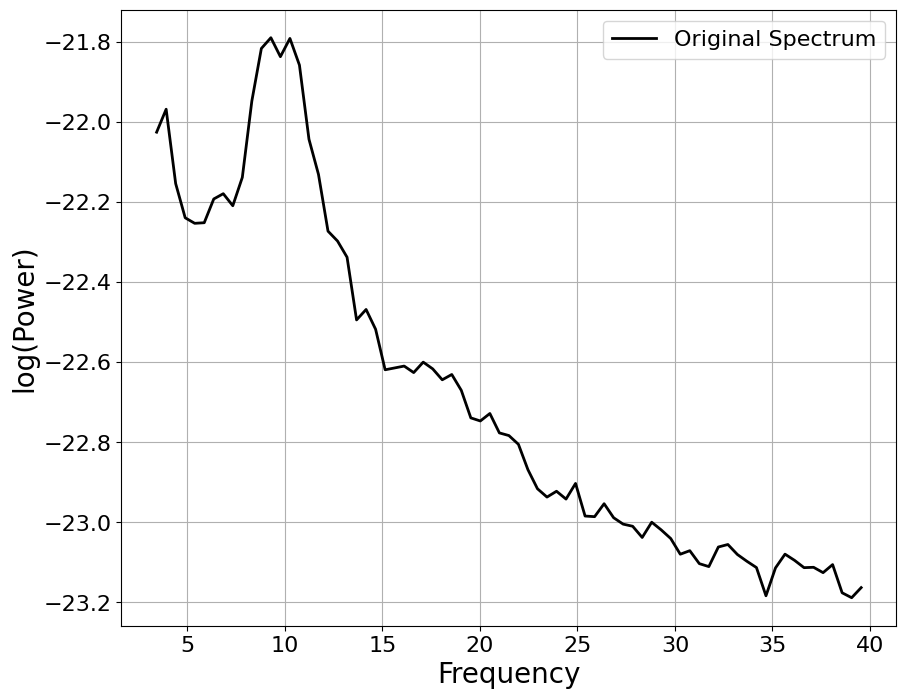

In [24]:
# Espectro de poder
fm.plot(plt_log)

El objeto `FOOOF` almacena internamente la mayoría de los pasos intermedios.

En este notebook primero ajustaremos el modelo completo de la forma habitual, pero luego recorreremos y visualizaremos cada uno de los pasos que el algoritmo siguió para llegar a ese ajuste final.

In [25]:
# Ajustar el modelo a los datos
fm.fit(freqs, spectrum, [3, 40])

***

<br/><br/>

## Paso 1: ajuste aperiódico inicial

Comenzamos realizando un ajuste inicial del componente aperiódico. El objetivo de este ajuste es obtener una aproximación inicial suficientemente buena para iniciar el proceso de ajuste.

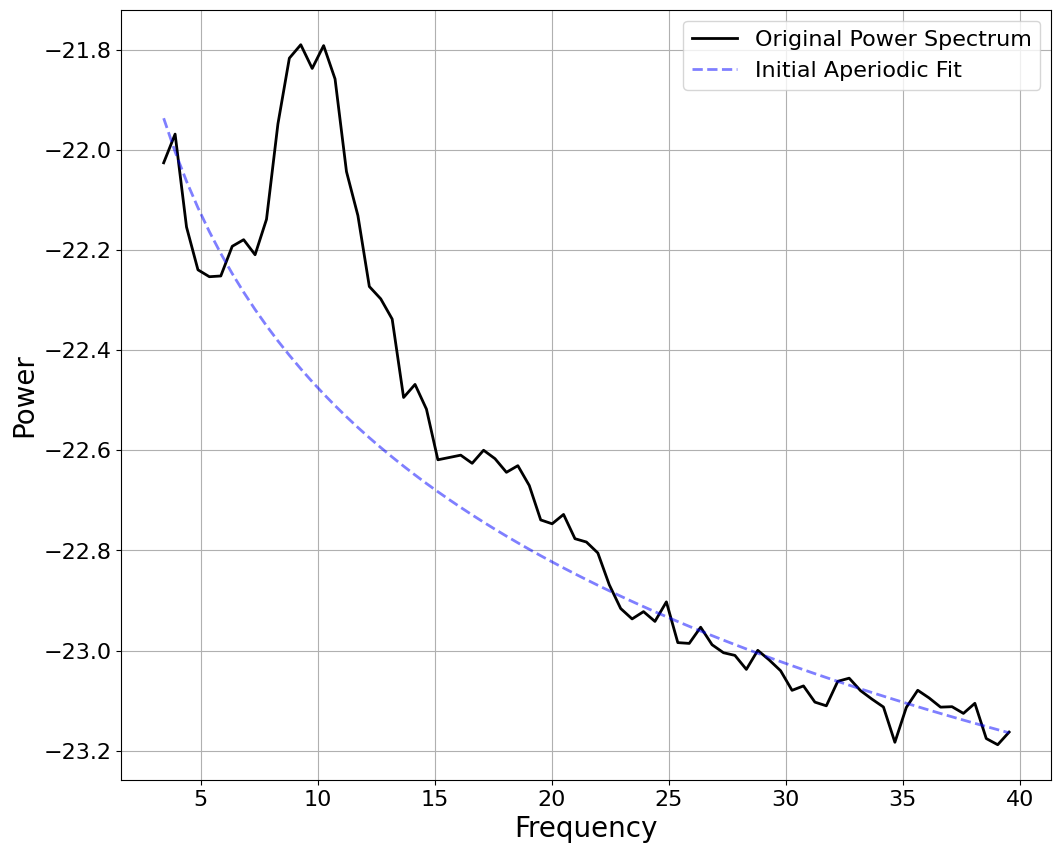

In [27]:
# Ajuste inicial aperiódico - un ajuste robusto, que excluye los valores atípicos.
# Esto recrea un ajuste inicial que no se almacena finalmente en el objeto FOOOF
init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))

# Graficar el ajuste aperiodico
_, ax = plt.subplots(figsize=(12, 10))
plot_spectrum(fm.freqs, fm.power_spectrum, plt_log,
              label='Original Power Spectrum', color='black', ax=ax)
plot_spectrum(fm.freqs, init_ap_fit, plt_log, label='Initial Aperiodic Fit',
              color='blue', alpha=0.5, linestyle='dashed', ax=ax)

***

<br/><br/>

## Paso 2: aplanar el espectro

El ajuste inicial se utiliza después para crear un espectro aplanado.

El ajuste aperiódico inicial se resta de los datos originales, dejando una versión aplanada de los datos que ya no contiene el componente aperiódico.

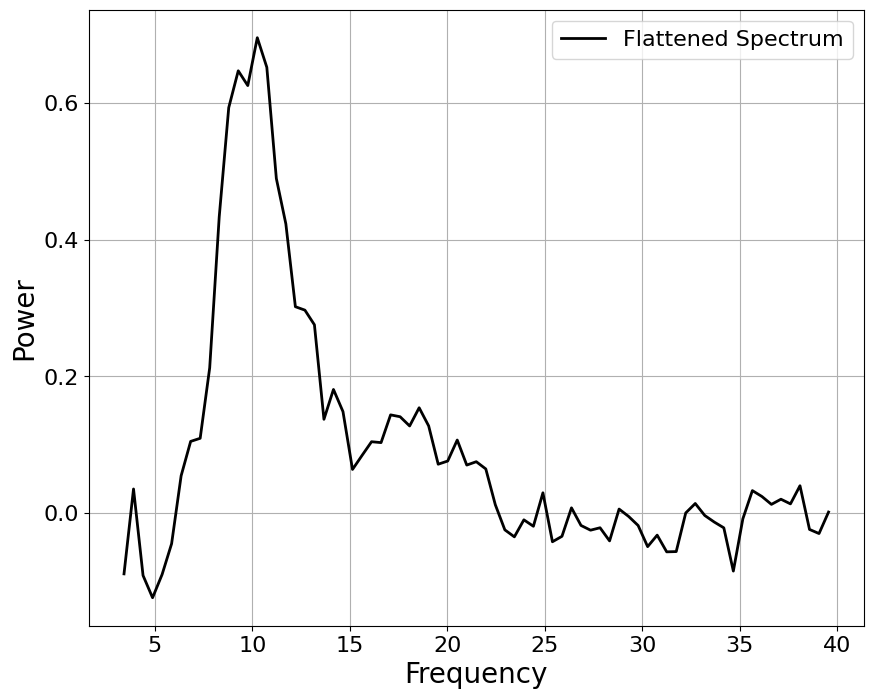

In [28]:
# Recalcular el espectro aplanado usando el ajuste aperiodico inicial
init_flat_spec = fm.power_spectrum - init_ap_fit

# Graficar el espectro de poder aplanado
plot_spectrum(fm.freqs, init_flat_spec, plt_log,
              label='Flattened Spectrum', color='black')

***

<br/><br/>

## Paso 3: detectar picos


El espectro aplanado se utiliza después para detectar picos. De esta manera podemos aislar mejor los picos en los datos, ya que la actividad aperiódica ha sido removida.

El algoritmo de ajuste utiliza un procedimiento iterativo para encontrar picos en el espectro aplanado.

En cada iteración:
- Se encuentra el punto máximo del espectro aplanado
  - Si este punto no supera el umbral relativo o absoluto de altura, el procedimiento se detiene
- Se ajusta una gaussiana alrededor de este punto máximo
- Esta gaussiana 'estimada' se resta del espectro aplanado
- El procedimiento continúa a una nueva iteración con la nueva versión del espectro aplanado, a menos que se haya alcanzado `max_n_peaks`

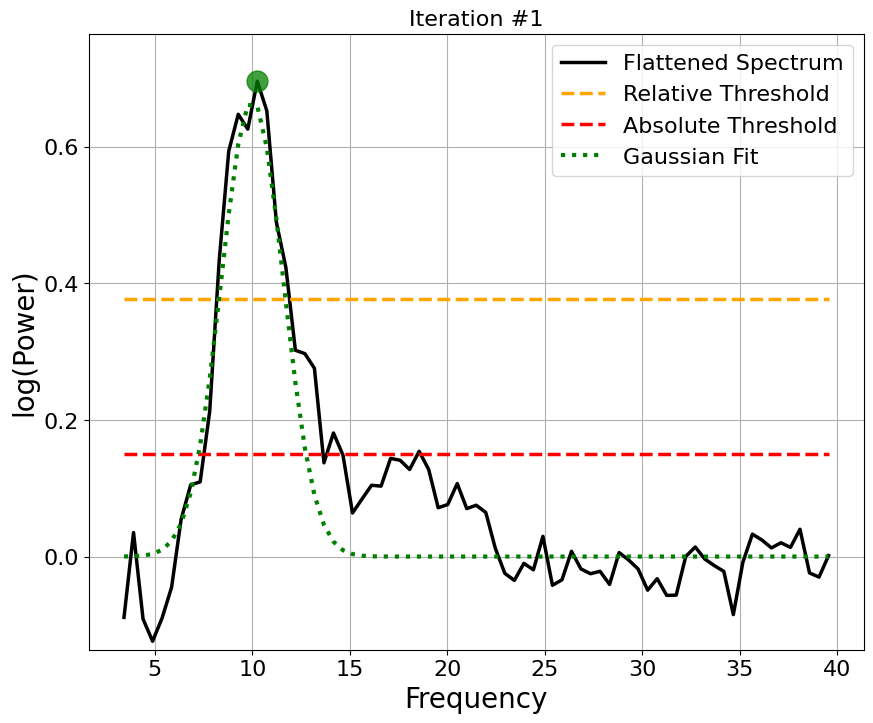

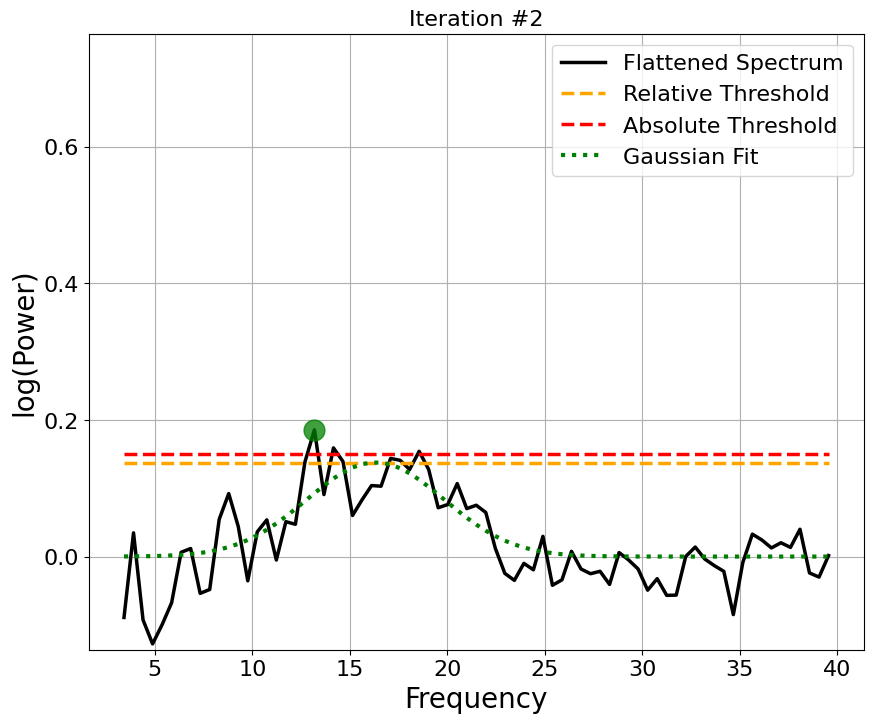

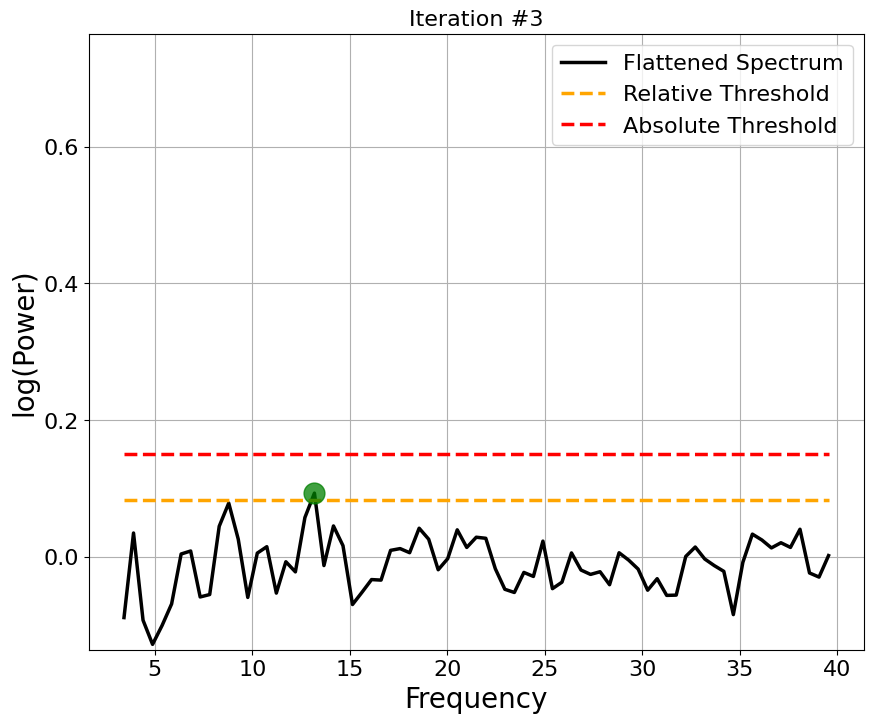

In [29]:
# Graficar el enfoque iterativo para encontrar picos a partir del espectro aplanado
plot_annotated_peak_search(fm)

*NOTA:*

El **umbral relativo** se define en términos de desviaciones estándar del espectro de potencia aplanado. Por defecto, el algoritmo `FOOOF` usa un umbral relativo de detección de picos de 2 desviaciones estándar.

El **umbral absoluto** es un umbral mínimo de potencia que un punto del espectro aplanado debe superar para identificarse como un pico. Aquí, el umbral absoluto se fija en 0.15 $\mu V^2$.

Tanto el umbral relativo `peak_threshold` como el umbral absoluto `min_peak_height` pueden establecerse como parámetros en el paso de inicialización del modelo.

***

<br/><br/>

## Paso 4: crear el ajuste completo de picos


Una vez que el procedimiento iterativo se ha detenido y los picos han sido identificados en el espectro aplanado, el conjunto de picos 'estimados' identificados se vuelve a ajustar de forma conjunta.
Esto crea el ajuste completo de picos de los datos.

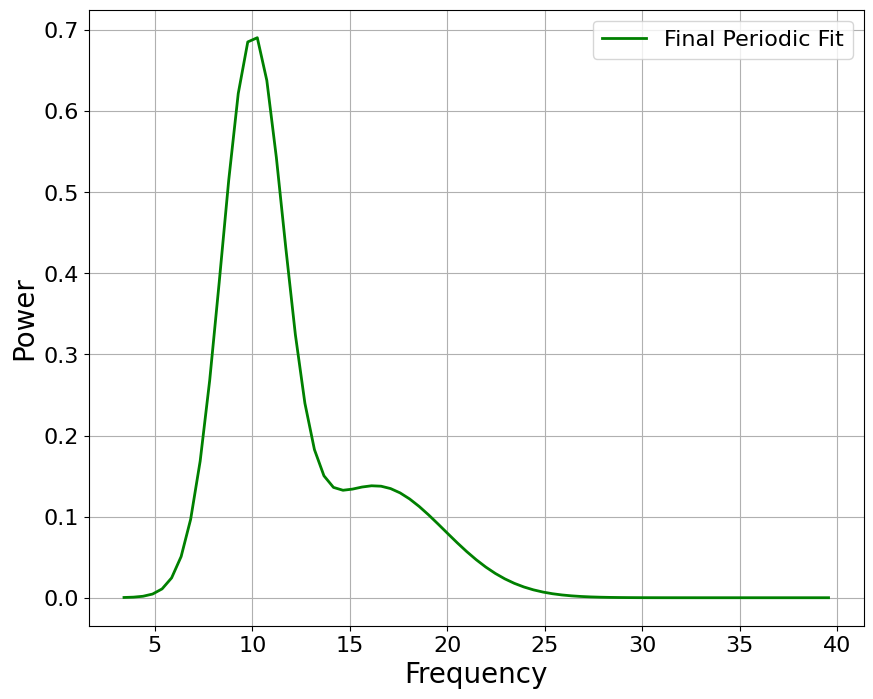

In [31]:
# Graficar el ajuste de picos: creado al volver a ajustar todos los picos candidatos juntos
plot_spectrum(fm.freqs, fm._peak_fit, plt_log, color='green', label='Final Periodic Fit')

***

<br/><br/>

## Paso 5: crear un espectro sin picos


Ahora que el ajuste del componente de picos está completo y disponible, se utiliza para intentar aislar un mejor ajuste aperiódico.

Para ello, el ajuste de los picos se remueve del espectro de potencia original, dejando un espectro 'solo aperiódico' para volver a ajustarlo.

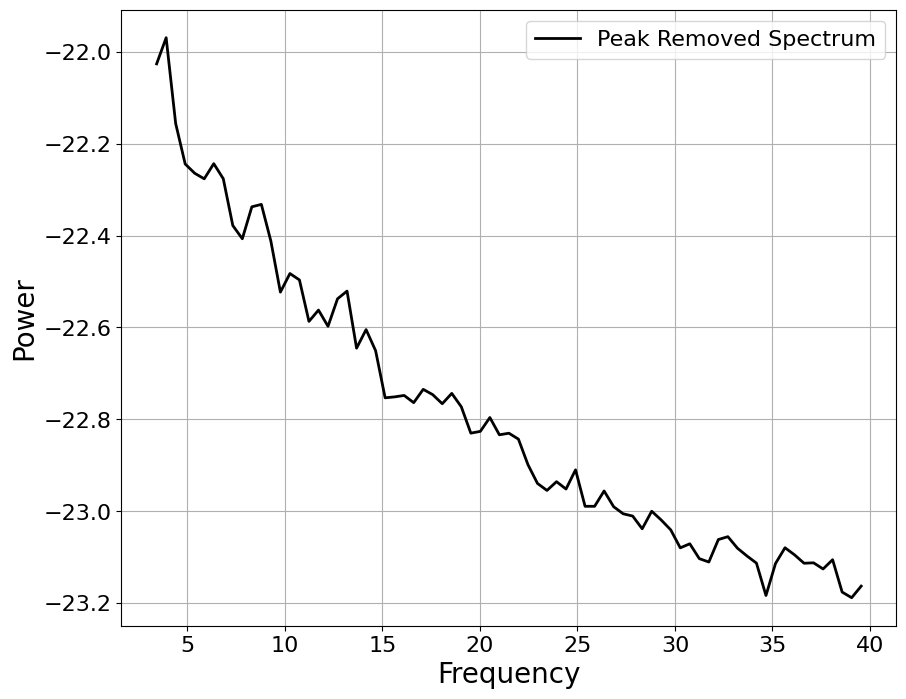

In [32]:
# Graficar el espectro con los picos removidos, 
# creado al remover el ajuste de picos del espectro original
plot_spectrum(fm.freqs, fm._spectrum_peak_rm, plt_log,
              label='Peak Removed Spectrum', color='black')

***

<br/><br/> 

## Paso 6: volver a ajustar el componente aperiódico


El ajuste inicial del componente aperiódico que hicimos fue un ajuste robusto usado únicamente para iniciar el proceso.

Con el espectro sin picos, ahora podemos volver a ajustar el componente aperiódico para estimar un mejor ajuste, sin que los picos interfieran.

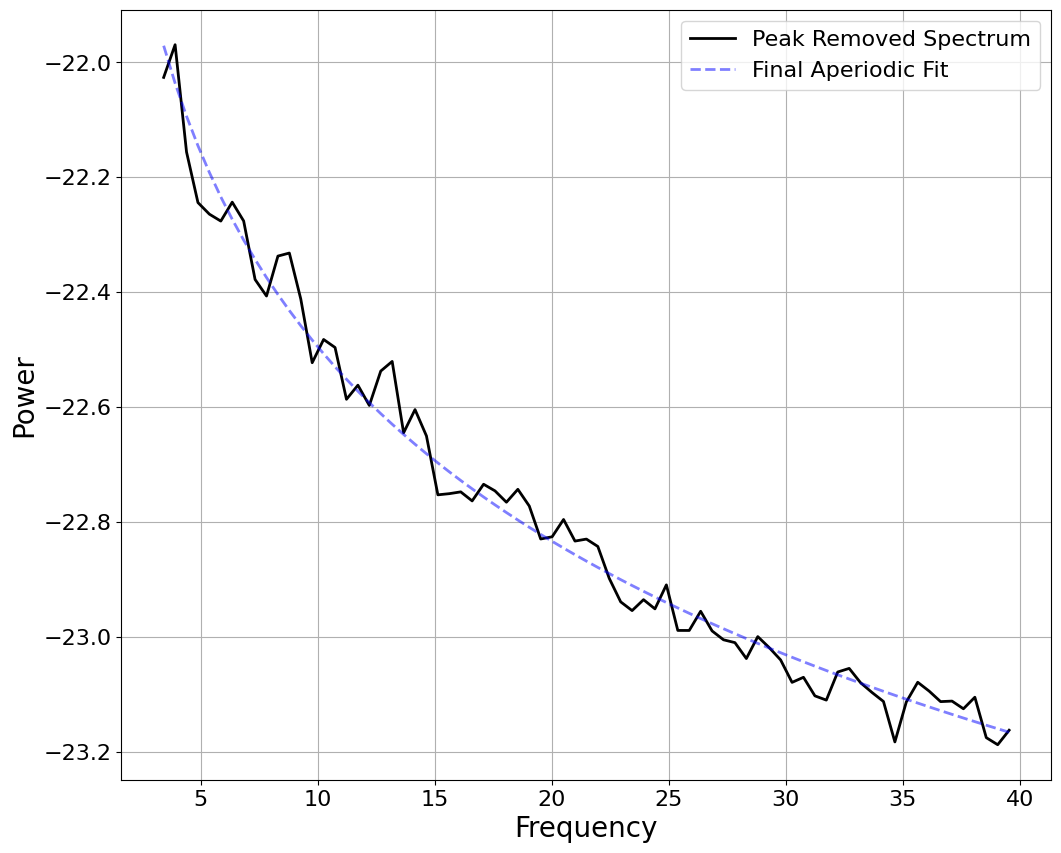

In [33]:
# Graficar el ajuste aperiodico final, calculado sobre el espectro de poder con los picos removidos
_, ax = plt.subplots(figsize=(12, 10))
plot_spectrum(fm.freqs, fm._spectrum_peak_rm, plt_log,
              label='Peak Removed Spectrum', color='black', ax=ax)
plot_spectrum(fm.freqs, fm._ap_fit, plt_log, label='Final Aperiodic Fit',
              color='blue', alpha=0.5, linestyle='dashed', ax=ax)

***

<br/><br/>

## Paso 7: combinar el ajuste completo del modelo


Ahora que tenemos el ajuste aperiódico final, podemos combinar los componentes aperiódicos para crear el ajuste completo del modelo.

Con este ajuste completo también podemos calcular métricas de calidad del ajuste, incluyendo el error del ajuste y el valor de $R^2$, comparando el modelo completo con los datos originales.

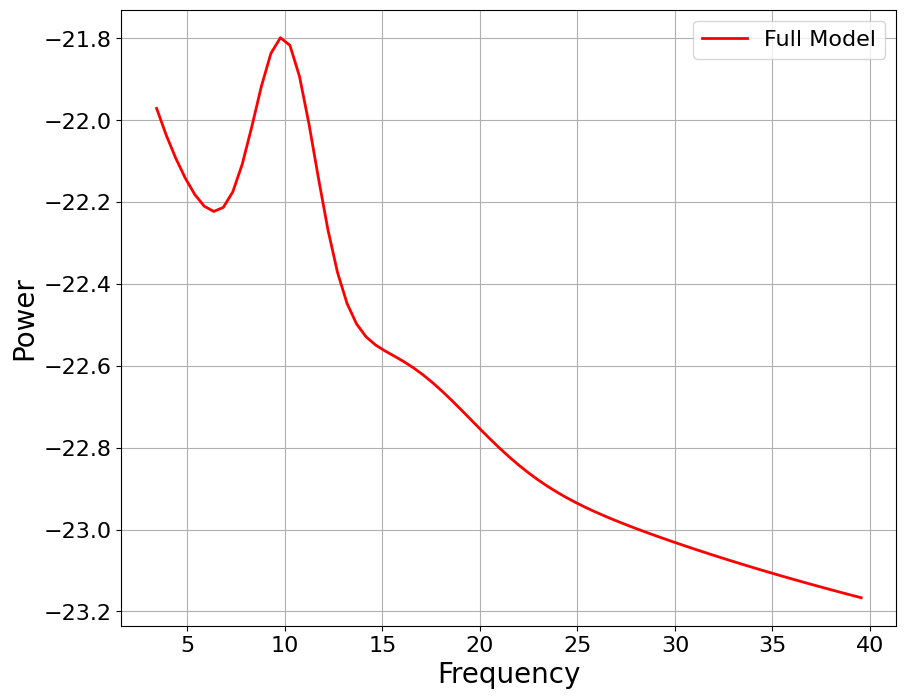

In [34]:
# Graficar el modelo completo, creado al combinar los ajustes de pico y aperiodico
plot_spectrum(fm.freqs, fm.fooofed_spectrum_, plt_log,
              label='Full Model', color='red')

La última etapa consiste en calcular las métricas de calidad del ajuste, es decir, el error del ajuste y el valor de $R^2$.

Al final del proceso de ajuste, el objeto del modelo también organiza los parámetros, por ejemplo, actualizando los parámetros gaussianos para convertirlos en parámetros de pico.

Estos resultados forman parte de lo que se almacena e imprime como resultados del modelo.

In [35]:
# Imprimir los resultados del modelo
fm.print_results()

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 3 - 40 Hz                        
                                 Frequency Resolution is 0.49 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -21.3713, 1.1239                                         
                                                                                                  
                                       2 peaks were found:                                        
          

En conjunto, el ajuste completo del modelo ya está disponible y puede graficarse.

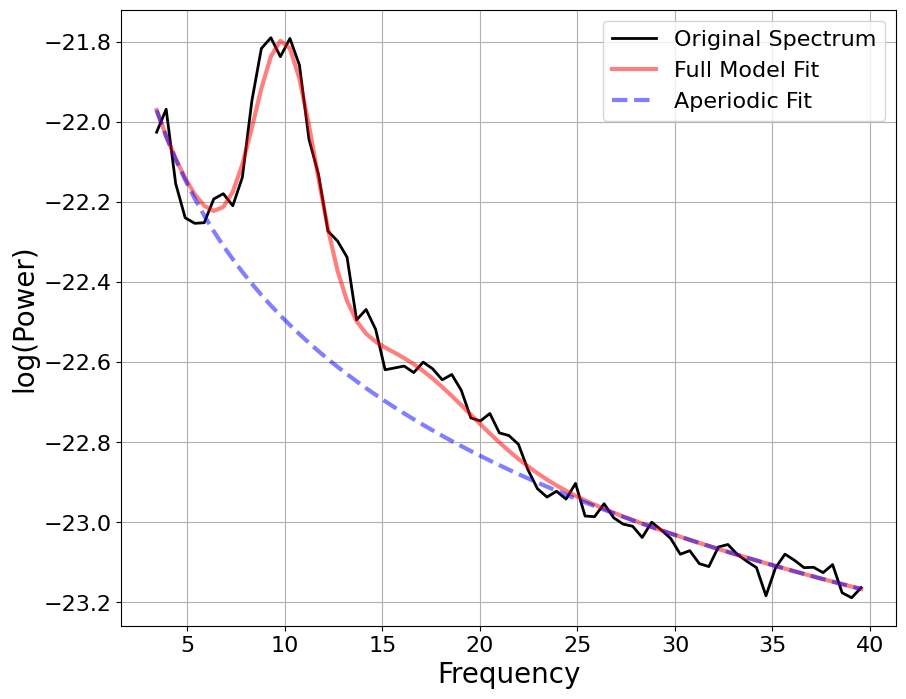

In [36]:
# Graficar el ajuste completo del espectro de poder. El ajuste final (rojo) y el ajuste aperiodico (azul) son los mismos que graficamos arriba.
# son los mismos que graficamos arriba.
fm.plot(plt_log)

***

<br/><br/>


## Conclusión


En este tutorial recorrimos el algoritmo de parametrización para ajustar modelos del espectro de potencia (power spectrum). Partiendo de un espectro de potencia, `FOOOF` ejecuta internamente el algoritmo de ajuste descrito en este tutorial; el proceso iterativo mostrado aquí no se grafica por defecto. La salida del algoritmo, es decir, el ajuste completo del modelo, incluye los parámetros de los componentes aperiódico y periódico del espectro de potencia, además de métricas de calidad de ajuste.

El modelo `FOOOF`, varias utilidades asociadas con análisis basados en parametrización espectral (spectral parameterization) y otros tutoriales están documentados en el repositorio fooof-tools y en el [sitio web de la API](https://fooof-tools.github.io/fooof/).

A continuación seguiremos explorando el método de parametrización espectral usando datos simulados.

***

<br/><br/>

## Adenda: atributos de los datos y componentes del modelo


Como quizá ya notaste a lo largo de este tutorial, el objeto `:class:\`~fooof.FOOOF\`` mantiene registro de algunas versiones de los datos originales, así como de los ajustes de componentes individuales del modelo, además del ajuste final completo, que es el resultado último del procedimiento de ajuste.

Estos atributos del objeto `FOOOF` se conservan al final del proceso de ajuste. Aunque se calculan principalmente para uso interno (por eso se consideran atributos 'privados', con guion bajo inicial), son accesibles y potencialmente útiles para algunos análisis, por lo que se describen brevemente aquí.

Componentes del modelo almacenados:

- Componente aperiódico: ``_ap_fit``

  - Es el ajuste solo del componente aperiódico de los datos.
  - Se calcula generando una reconstrucción de los parámetros aperiódicos medidos.

- Componente periódico: ``_peak_fit``

  - Es el ajuste solo del componente periódico (o de picos) de los datos.
  - Se calcula generando una reconstrucción de los parámetros periódicos (picos) medidos.

Atributos de datos almacenados:

- Espectro aplanado: ``_spectrum_flat``

  - Son los datos originales con el componente aperiódico removido.
  - Se calcula como ``power_spectrum`` - ``_ap_fit``.

- Espectro sin picos: ``_spectrum_peak_rm``

  - Son los datos originales con el componente periódico (picos) removido.
  - Se calcula como ``power_spectrum`` - ``_peak_fit``.